In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.widgets import Slider
%matplotlib widget

########################################################   CONSTANTS   ########################################################
SunPower = 1361                                     # Raw power of sunlight when it reaches the satellite in W/m2
BOLSolarCellEfficiency = 0.3                        # Beginning Of Life efficiency of the Solar Cells
EOLSolarCellEfficiency = 0.209                      # End Of Life efficiency of the Solar Cells
BatteryDegradationFittingConstant = 0.0000348       # Curve fitting constant in s^-1/2

####################################################   ITERATING CONSTANTS   ##################################################
# Each value is defined as: value = [minimum, maximum, number_of_points]
PanelSurface = [3, 5.25, 21]                        # Effective surface of the Solar Panels (just the surface of the cells)
BOLBatteryCapacity = [400, 2000, 21]                # Initial capacity of the battery in Wh
PowerDraw = [200, 1500, 21]                         # Power drawn by the system 

#######################################################   MAIN PROGRAM   ######################################################
# Import data from csv files
SolarIntensity = pd.read_csv('Solar_intensity.csv')['Intensity']
SunVector = pd.read_csv('sun_vector.csv')[['x (km)', 'y (km)', 'z (km)']]

# Check if the files match dates and times
Times = pd.read_csv('Solar_intensity.csv')[['Time (UTCG)']]
Times = Times.rename(columns={'Time (UTCG)': 'Solar Intensity'})
Times['Sun Vector'] = pd.read_csv('sun_vector.csv')['Time (UTCG)']
Times['Solar Intensity'] = pd.to_datetime(Times['Solar Intensity'])
Times['Sun Vector'] = pd.to_datetime(Times['Sun Vector'])
if (Times['Sun Vector'] != Times['Solar Intensity']).any():
    if len(Times['Sun Vector']) != len(Times['Solar Intensity']):
        raise ValueError('>>> ERROR: Files have different number of rows. Files may be from different simulations')
    else:
        raise ValueError('>>> ERROR: Timestamps are not the same between files. Files may be from different simulations')
    
# Create timesteps for calculations
Times['Timestep (s)'] = Times['Solar Intensity'].diff().dt.total_seconds().fillna(0)
Times['Timestep (h)'] = Times['Timestep (s)']/3600
Times['CumulativeTime'] = Times['Timestep (s)'].cumsum()

# Calculate the sines of the angles of incidence of the sun from each plane
SunVector['Sine of X Face Angle'] = SunVector['x (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2)))
SunVector['Sine of Y Face Angle'] = SunVector['y (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2)))
SunVector['Sine of Z Face Angle'] = SunVector['z (km)']/(np.sqrt((SunVector['x (km)']**2) + (SunVector['y (km)']**2) + (SunVector["z (km)"]**2)))

# Calculate efficiency of the Solar Cells for the duration of the mission
PanelEfficiency = pd.Series(np.linspace(BOLSolarCellEfficiency, EOLSolarCellEfficiency, num=len(Times['Sun Vector'])))

# Calculate generation for every panel size
Generation = {}
for IterationPanelSurface in np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2]):
    # Calculate the power generation from each satellite face
    Generation[f'{IterationPanelSurface}m^2'] = pd.DataFrame()
    Generation[f'{IterationPanelSurface}m^2']['W generated in face X'] = SunPower * SunVector['Sine of X Face Angle'] * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)
    Generation[f'{IterationPanelSurface}m^2']['W generated in face Y'] = SunPower * SunVector['Sine of Y Face Angle'] * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)
    Generation[f'{IterationPanelSurface}m^2']['W generated in face Z'] = SunPower * SunVector['Sine of Z Face Angle'] * PanelEfficiency * IterationPanelSurface * (SolarIntensity/100)

# Calculate battery degradation for every battery size
RealBatteryCapacity = pd.DataFrame()
BatteryDegradationFactor = (1 - (BatteryDegradationFittingConstant * np.sqrt(Times['CumulativeTime'])))
for IterationBOLBatteryCapacity in np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2]):
    # Calculate the degradation of the battery in each point in time
    RealBatteryCapacity[f'{IterationBOLBatteryCapacity}Wh'] = IterationBOLBatteryCapacity * BatteryDegradationFactor

# Create a key for every panel position
PanelPositions = [['W generated in face X', 'Panels in face X'],
                  ['W generated in face Y', 'Panels in face Y'],
                  ['W generated in face Z', 'Panels in face Z']]

# Initialize a list of every configuration that goes out of battery at any point
OutOfBattery = []

# Run through every combination of values to calculate state of charge at every point of the orbit in every configuration
Charge = {}
for IterationPanelSurface in tqdm(np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2]), desc='Loading'):
    Charge[f'{IterationPanelSurface}m^2'] = {}
    for IterationBOLBatteryCapacity in tqdm(np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2]), desc='Battery sizes', leave=False):
        Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'] = {}
        for IterationPowerDraw in tqdm(np.linspace(PowerDraw[0], PowerDraw[1], num=PowerDraw[2]), desc='Power configs', leave=False):
            Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W'] = pd.DataFrame()
            for PanelPositionIndex in range(3):
                # Define route to the df being built and fill it
                dfActual = Charge[f'{IterationPanelSurface}m^2'][f'{IterationBOLBatteryCapacity}Wh'][f'{IterationPowerDraw}W']
                dfActual[PanelPositions[PanelPositionIndex][1]] = np.nan

                # Redefine df as np arrays for faster calculations
                GenerationArray = Generation[f'{IterationPanelSurface}m^2'][PanelPositions[PanelPositionIndex][0]].to_numpy()
                MaximumBatteryArray = RealBatteryCapacity[f'{IterationBOLBatteryCapacity}Wh'].to_numpy()

                # Calculate energy gained or lost
                NetEnergy = (GenerationArray - IterationPowerDraw) * Times['Timestep (h)']

                # Throwaway list for value storage pre-dump
                ChargeList = [IterationBOLBatteryCapacity]

                # Reinitialize flag for going out of battery
                BatteryDown = 0
                for i in range(len(Times['Sun Vector'])-1):
                    # Calculate state of charge
                    NextValue = ChargeList[-1] + NetEnergy[i+1]

                    # Check if energy storage is within its maximum and minimum values
                    if NextValue > MaximumBatteryArray[i+1]:
                        ChargeList.append(MaximumBatteryArray[i+1])
                    elif NextValue < 0:
                        ChargeList.append(0)
                        # Add configuration to the list of going out of battery
                        if BatteryDown == 0:
                            OutOfBattery.append([f'{IterationPanelSurface}m^2', f'{IterationBOLBatteryCapacity}Wh', f'{IterationPowerDraw}W', PanelPositions[PanelPositionIndex][1]])
                            BatteryDown = 1
                    else:
                        ChargeList.append(NextValue)
                    
                # Dump the throwaway list into the df
                dfActual[PanelPositions[PanelPositionIndex][1]] = ChargeList

In [ ]:
# Print every configuration that went out of battery
print(OutOfBattery)

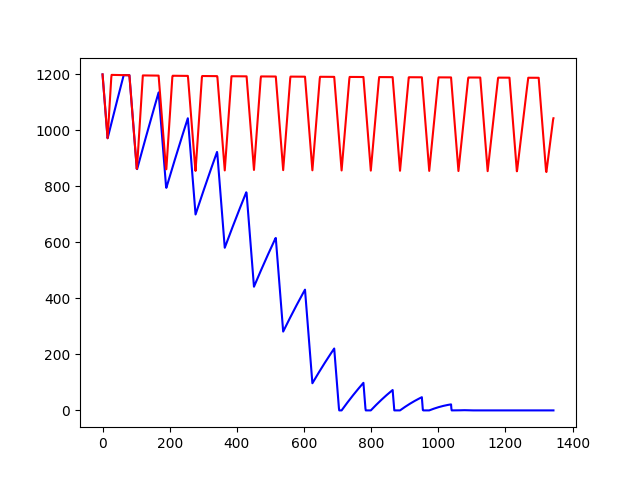

In [3]:
# Create plot
plt.figure("Charge respect time")
plt.title("Charge respect time")
plt.clf()

# Decide configuration to plot
FirstPanelValue = float(PanelSurface[0])
LastPanelValue = float(PanelSurface[1])
BatteryValue = np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2])[int(BOLBatteryCapacity[2]/2)]
PowerValue = np.linspace(PowerDraw[0], PowerDraw[1], num=PowerDraw[2])[int(PowerDraw[2]/2)]

# Plot data
plt.plot(Charge[f'{FirstPanelValue}m^2'][f'{BatteryValue}Wh'][f'{PowerValue}W']['Panels in face Y'], color = 'blue')
plt.plot(Charge[f'{LastPanelValue}m^2'][f'{BatteryValue}Wh'][f'{PowerValue}W']['Panels in face Y'], color = 'red')
plt.show()

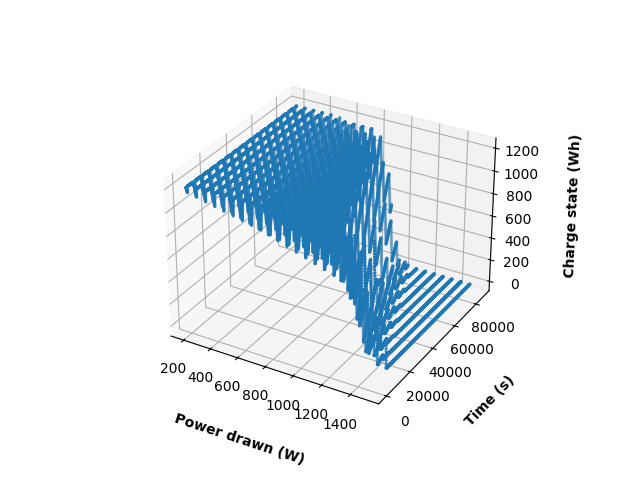

In [15]:
# Configure plot
plt.close()
plt.figure('Charge graph for every power draw')
plt.title('Charge graph for every power draw')
plt.clf()
ax = plt.axes(projection='3d')

# Set lables for every axis
ax.set_xlabel('Power drawn (W)', labelpad = 15, fontweight = 'bold')
ax.set_ylabel('Time (s)', labelpad = 15, fontweight = 'bold')
ax.set_zlabel('Charge state (Wh)', labelpad = 15, fontweight = 'bold')

# Set the Panel and Battery sizes
PanelValue = np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2])[int(PanelSurface[2]/2)]
BatteryValue = np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2])[int(BOLBatteryCapacity[2]/2)]

# Collect the charge curves for every power draw
xdata = []
ydata = Times['CumulativeTime']
Z = []
for Xvalue in np.linspace(PowerDraw[0], PowerDraw[1], num=PowerDraw[2]):
    xdata.append(Xvalue)
    temp = []
    for j in range(len(Times['CumulativeTime'])):
        temp.append(Charge[f'{PanelValue}m^2'][f'{BatteryValue}Wh'][f'{Xvalue}W']['Panels in face Y'].iloc[j])
    Z.append(temp)
Z = np.array(Z)
Z = Z.T
X, Y = np.meshgrid(xdata, ydata)

ax.scatter(X, Y, Z, s=2)
plt.show()

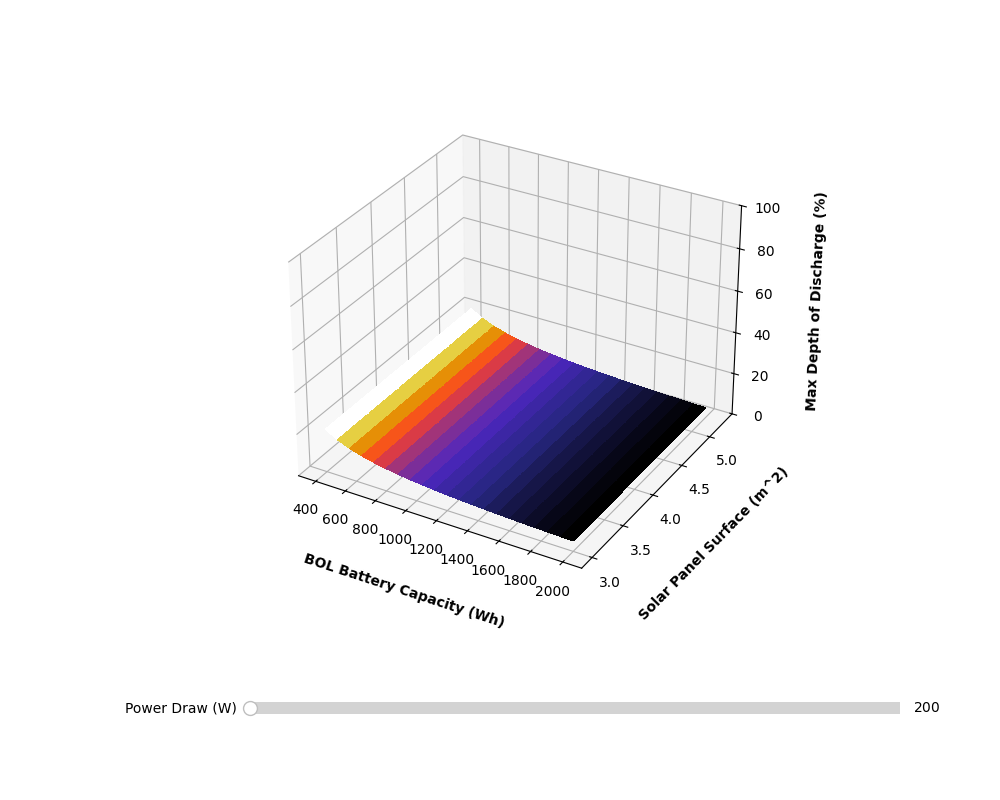

In [16]:
# Calculate values to plot
def CalculateDoD(potencia):
    ZValues = []
    PowerToPlot= f'{potencia}W' 
    
    for Capacity in xdata:
        ZRows = []
        for Surface in ydata:
            # Calculate maximum Depth of Discharge for every configuration
            MinimumCharge = min(Charge[f'{Surface}m^2'][f'{Capacity}Wh'][PowerToPlot]['Panels in face Y'])
            DoD = 100 - ((MinimumCharge * 100) / Capacity)
            ZRows.append(DoD)
        ZValues.append(ZRows)
        
    # Return the array with the minimum charge values
    return np.array(ZValues).T

# Redraw graph for a new power value
def UpdateGraph(val):
    # Clear previous surface
    global surf # recall global variable
    surf.remove()

    # Get new power value
    NewPowerValue = PowerSlider.val
    Z_nuevo = CalculateDoD(NewPowerValue)
    
    # Reload graph
    surf = ax.plot_surface(X, Y, Z_nuevo, cmap=cm.CMRmap_r, linewidth=0, antialiased=False)
    fig.canvas.draw_idle()

# Graph config
plt.close()
fig = plt.figure('Max DoD for every panel size, battery size and power draw', figsize=(10, 8))
plt.subplots_adjust(bottom=0.25) 
ax = plt.axes(projection='3d')

# Axis names
ax.set_xlabel('BOL Battery Capacity (Wh)', labelpad=15, fontweight='bold')
ax.set_ylabel('Solar Panel Surface (m^2)', labelpad=15, fontweight='bold')
ax.set_zlabel('Max Depth of Discharge (%)', labelpad=15, fontweight='bold')
ax.set_zlim(0, 100) 

# Define the values to plot
xdata = np.linspace(BOLBatteryCapacity[0], BOLBatteryCapacity[1], num=BOLBatteryCapacity[2])
ydata = np.linspace(PanelSurface[0], PanelSurface[1], num=PanelSurface[2])
PowerDraws = np.linspace(PowerDraw[0], PowerDraw[1], num=PowerDraw[2])
X, Y = np.meshgrid(xdata, ydata)
Z = CalculateDoD(PowerDraws[0])

# Plot initial surface
surf = ax.plot_surface(X, Y, Z, cmap=cm.CMRmap, linewidth=0, antialiased=False)

# Configure the slider
PowerSlider = Slider(
    ax = plt.axes([0.25, 0.1, 0.65, 0.03]),     # Where the slider is drawn
    label = 'Power Draw (W)',
    valmin = PowerDraws[0],
    valmax = PowerDraws[-1],
    valinit = PowerDraws[0],
    valstep = PowerDraws                        # Values the slider offers as posible
)

# Conect changes on the slider with the function to update the graph
PowerSlider.on_changed(UpdateGraph)

plt.show()